# Linear Regression with One Variable: Part 2

In [2]:
# requirements
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# Gradient Descent (Parameter Learning)

The gradient descent (GD) is an algorithm used to estimate the parameters in the hypothesis function. As we have our hypothesis function and a way of measuring how well it fits into the data $J$, we can compute the GD.

Imagine that we graph our cost function based on its fields $\theta_0$ amd $\theta_1$. We are graphing the parameter range of our hypothesis function and the cost resulting from selecting a particular set of parameters.

We put $\theta_0$ on the $x$ axis and $\theta_1$ on the $y$ axis, with the cost function on the vertical $z$ axis. The points on our graph will be the result of the cost function using our hypothesis with those specific theta parameters. The graph below depicts such a setup.

<img src="Fig/GD.png" />

We will know that we have succeeded when our cost function is at the very bottom of the pits in our graph, i.e. when its value is the minimum. The red arrows show the minimum points in the graph.

The way we do this is by taking the derivative (the tangential line to a function) of our cost function. The slope of the tangent is the derivative at that point and it will give us a direction to move towards. We make steps down the cost function in the direction with the steepest descent. The size of each step is determined by the parameter $\alpha$, which is called the learning rate.

For example, the distance between each 'star' in the graph above represents a step determined by our parameter $\alpha$. A smaller $\alpha$ would result in a smaller step and a larger $\alpha$ results in a larger step. The direction in which the step is taken is determined by the partial derivative of $J(\theta_0,\theta_1)$. Depending on where one starts on the graph, one could end up at different points.

## The GD Algorithm

repeat until convergence:{

$$
\theta_j := \theta_j - \alpha \frac{\partial}{\partial \theta_j}J(\theta_0,\theta_1)
$$

}
where $j=0,1$ represents the feature index number.

At each iteration $j$, one should simultaneously update the parameters $\theta_0$, $\theta_1$. Updating a specific parameter prior to calculating another one on the $j^{(th)}$ iteration would yield to a wrong implementation.

Suppose the scenario where we used one parameter $\theta_1$ and plotted its cost function to implement a gradient descent. Our formula for a single parameter is:

$$
\theta_1 := \theta_1 - \alpha \frac{\partial}{\partial \theta_1}J(\theta_1)
$$

thus, when $ \frac{\partial}{\partial \theta_1}J(\theta_1) \geq 0$, $\theta_1$ decreases and when $\frac{\partial}{\partial \theta_1}J(\theta_1) \leq 0$, $\theta_1$ increases.

We should also adjust our parameter $\alpha$ to ensure that the gradient descent algorithm converges in a reasonable time. Failure to converge or too much time to obtain the minimum value imply that our step size is wrong.

- If $\alpha$ is too small, GD can be slow
- If $\alpha$ is too large, GD can overshoot the minimum. It may fail to converge or even diverge.

However, the GD can converge with fixed $\alpha$ as $\frac{\partial}{\partial \theta_j}J(\theta_0,\theta_1)$ approaches 0. As we approach the bottom of our convex function GD takes automatically samller steps. At the minimum, the derivative will always be 0 and thus we get:

$$
\theta_1 := \theta_1 - \alpha \times 0
$$

## Gradient Descent For Linear Regression

With linear regresión we aim to fit the data to the model:

$$
h_\theta(x) = \theta_0 + \theta_1 x
$$

When specifically applied to the case of one variable linear regression, the GD algorithm is derived as:

repeat until convergence:{
$$
\theta_0 := \theta_0 - \alpha \frac{\partial}{\partial \theta_0}J(\theta_0, \theta_1)
$$

$$
\theta_1 := \theta_1 - \alpha \frac{\partial}{\partial \theta_1}J(\theta_0, \theta_1)
$$
}

solving the partial derivatives lead us to:

repeat until convergence:{
$$
\theta_0 := \theta_0 - \alpha \frac{1}{m}\sum_{i = 1}^m (h_\theta (x_i) - y_i)
$$

$$
\theta_1 := \theta_1 - \alpha \frac{1}{m}\sum_{i = 1}^m ((h_\theta (x_i) - y_i)x_i)
$$
}

where 
- $m$ is the size of the training set,
- $\theta_0$ a is the $y$ intercept parameter,
- $\theta_1$ is the slope parameter,
- $x_i$ and $y_i$ are values of the given training set.

**Note:** $\theta_0$ and $\theta_1$ must change simultaneously

The point of all this is that if we start with a guess for our hypothesis and then repeatedly apply these gradient descent equations, our hypothesis will become more and more accurate.

This method looks at every example in the entire training set on every step, and is called **batch gradient descent**. 

Note that, while gradient descent can be susceptible to local minima in general, the optimization problem we have posed here for linear regression has only one global, and no other local, optima; thus gradient descent always converges (assuming the learning rate $\alpha$ is not too large) to the global minimum. Indeed, $J$ is a convex quadratic function.

# Example

Use the GD for linear regresion and **debug** GD making a plot with number of iterations on the $x$-axis. Now plot the cost function, $J(\theta)$ over the number of iterations of gradient descent. If $J(\theta)$ ever increases, then you probably need to decrease $\alpha$.

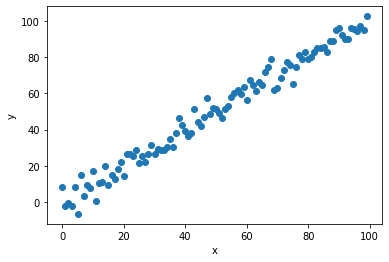

In [9]:
m = 100
np.random.seed(1)
noise = np.random.randn(m)
X = np.arange(0, m)
Y = np.arange(0, m) + 5*noise

plt.scatter(X, Y)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

theta =  1.008454751158394


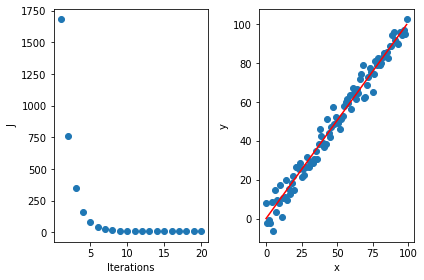

In [26]:
iterations = 20
alpha = 1e-4
theta = 0

J = np.zeros(iterations)
for k in range(iterations):
    h = theta*X
    sqerror = np.zeros(m)
    aux = np.zeros(m)
    for i in range(m):
        sqerror[i] = (h[i] - Y[i])**2
        aux[i] = (h[i] - Y[i])*X[i]
    J[k] = 1/(2*m)*np.sum(sqerror)
    theta = theta - alpha*(1/m)*np.sum(aux)

print('theta = ', theta)

iteration = np.arange(1, iterations+1)

plt.subplot(1, 2, 1)
plt.scatter(iteration, J)
plt.xlabel('Iterations')
plt.ylabel('J')

plt.subplot(1, 2, 2)
plt.scatter(X, Y)
plt.plot(X, X*theta, 'r')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
plt.show()

It has been proven that if learning rate $\alpha$ is sufficiently small, then $J(\theta)$ will decrease on every iteration.

To summarize:

If $\alpha$ is too small: slow convergence.

If $\alpha$ is too large: may not decrease on every iteration and thus may not converge.

**Automatic convergence test:** Declare convergence if $J(\theta)$ decreases by less than E in one iteration, where E is some small value such as $10^{−3}$. However in practice it's difficult to choose this threshold value.